# Dynamic CSV Explorer

This notebook automatically inspects **any** CSV file you point it at and generates
appropriate visualizations based on the data types it finds (numeric, categorical,
datetime, text/high-cardinality). You should not need to edit any code below —
just change `CSV_PATH` in the next cell and re-run.


In [1]:
# ============================================================
# CONFIG — the only thing you should ever need to change
# ============================================================
CSV_PATH = "genai_llm_usage_dataset_100.csv"   # <-- point this at your CSV file
#CSV_PATH = "books.csv"
# Optional tuning knobs (safe to leave as-is)
MAX_CATEGORIES_FOR_BAR = 30      # skip bar charts for columns with more unique values than this
MAX_CATEGORIES_FOR_PIE = 8       # only pie-chart columns with few unique values
MAX_NUMERIC_FOR_PAIRPLOT = 6     # cap on number of numeric cols shown in pairplot/correlation
SAMPLE_ROWS_FOR_TEXT = 5         # example rows shown for text-heavy columns


In [2]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)


## 1. Load the CSV

In [3]:
df = pd.read_csv('genai_llm_usage_dataset_1000.csv')
#df = pd.read_csv('books.csv')

# Try to auto-parse any column that looks like a date/time
for col in df.columns:
    if df[col].dtype == object:
        sample = df[col].dropna().astype(str).head(20)
        if len(sample) == 0:
            continue
        parsed = pd.to_datetime(sample, errors="coerce", infer_datetime_format=True)
        if parsed.notna().mean() > 0.8:  # most values parse as dates
            df[col] = pd.to_datetime(df[col], errors="coerce", infer_datetime_format=True)

print(f"Loaded '{'books.csv'}' — {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Loaded 'books.csv' — 1000 rows x 14 columns


,session_id,model_name,application_domain,task_type,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
0,1,GPT-4o,Healthcare,Summarization,1319,2455,0.17,0.87,0,3.76,0,4,0.0236,1
1,2,GPT-4o,Customer Support,Summarization,486,1425,0.76,0.51,0,2.36,1,5,0.0236,0
2,3,Gemma 3,Retail,Classification,1439,1648,0.63,0.64,0,3.68,1,4,0.0139,0
3,4,Gemma 3,Retail,Summarization,1662,2812,0.07,0.73,0,3.25,1,4,0.0374,0
4,5,Gemma 3,Finance,Classification,1452,1678,0.10,0.83,0,8.04,0,4,0.0171,0


## 2. Column overview & auto-detected types

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           1000 non-null   int64  
 1   model_name           1000 non-null   str    
 2   application_domain   1000 non-null   str    
 3   task_type            1000 non-null   str    
 4   prompt_length        1000 non-null   int64  
 5   total_tokens         1000 non-null   int64  
 6   temperature          1000 non-null   float64
 7   top_p                1000 non-null   float64
 8   rag_enabled          1000 non-null   int64  
 9   latency_sec          1000 non-null   float64
 10  hallucination_flag   1000 non-null   int64  
 11  user_satisfaction    1000 non-null   int64  
 12  estimated_cost_usd   1000 non-null   float64
 13  successful_response  1000 non-null   int64  
dtypes: float64(4), int64(7), str(3)
memory usage: 135.8 KB


In [5]:
# ============================================================
# Auto-classify columns into: numeric, datetime, categorical, text/high-cardinality
# ============================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
datetime_cols = df.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns.tolist()

remaining = [c for c in df.columns if c not in numeric_cols and c not in datetime_cols]

categorical_cols, text_cols = [], []
for c in remaining:
    nunique = df[c].nunique(dropna=True)
    # heuristic: low cardinality relative to row count -> categorical, else free text
    if nunique <= max(MAX_CATEGORIES_FOR_BAR, int(len(df) * 0.5)) and nunique <= 50:
        categorical_cols.append(c)
    else:
        text_cols.append(c)

# Boolean-like numeric columns (only 0/1 or True/False) treated as categorical too
bool_like = [c for c in numeric_cols if df[c].dropna().isin([0, 1]).all() and df[c].nunique() <= 2]
for c in bool_like:
    numeric_cols.remove(c)
    categorical_cols.append(c)

print("Numeric columns:    ", numeric_cols)
print("Datetime columns:   ", datetime_cols)
print("Categorical columns:", categorical_cols)
print("Text/high-card cols:", text_cols)


Numeric columns:     ['session_id', 'prompt_length', 'total_tokens', 'temperature', 'top_p', 'latency_sec', 'user_satisfaction', 'estimated_cost_usd']
Datetime columns:    []
Categorical columns: ['model_name', 'application_domain', 'task_type', 'rag_enabled', 'hallucination_flag', 'successful_response']
Text/high-card cols: []


## 3. Summary statistics

In [6]:
if numeric_cols:
    display(df[numeric_cols].describe().T)
else:
    print("No numeric columns found.")


,count,mean,std,min,25%,50%,75%,max
session_id,1000.0,500.500000,288.819436,1.0000,250.7500,500.5000,750.2500,1000.0000
prompt_length,1000.0,1022.780000,574.062391,12.0000,520.7500,1056.0000,1493.2500,2000.0000
total_tokens,1000.0,1636.763000,681.390085,71.0000,1118.0000,1635.5000,2142.2500,3158.0000
temperature,1000.0,0.747280,0.425450,0.0000,0.3700,0.7400,1.1100,1.5000
top_p,1000.0,0.742070,0.142340,0.5000,0.6200,0.7400,0.8600,1.0000
latency_sec,1000.0,5.368310,2.375312,0.3100,3.3000,5.4600,7.3700,10.4400
user_satisfaction,1000.0,4.345000,0.581647,3.0000,4.0000,4.0000,5.0000,5.0000
estimated_cost_usd,1000.0,0.018026,0.011971,0.0005,0.0084,0.0154,0.0249,0.0603


In [7]:
if categorical_cols:
    for c in categorical_cols:
        print(f"\n--- {c} ---")
        display(df[c].value_counts(dropna=False).head(10).to_frame("count"))
else:
    print("No categorical columns found.")



--- model_name ---


,count
model_name,
Mistral Large,193
Qwen 2.5,177
GPT-4o,167
Gemma 3,164
Claude 3.7,151
Llama 3.1,148



--- application_domain ---


,count
application_domain,
Customer Support,165
Education,156
Retail,154
Finance,137
Healthcare,131
Coding,130
Legal,127



--- task_type ---


...

,count
rag_enabled,
1,502
0,498



--- hallucination_flag ---


,count
hallucination_flag,
1,507
0,493



--- successful_response ---


,count
successful_response,
0,798
1,202


## 4. Missing values

In [8]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing) * 0.4)))
    sns.barplot(x=missing.values, y=missing.index, ax=ax, color="steelblue")
    ax.set_xlabel("Missing count")
    ax.set_title("Missing values per column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")


No missing values detected.


## 5. Distributions of numeric columns (histograms)

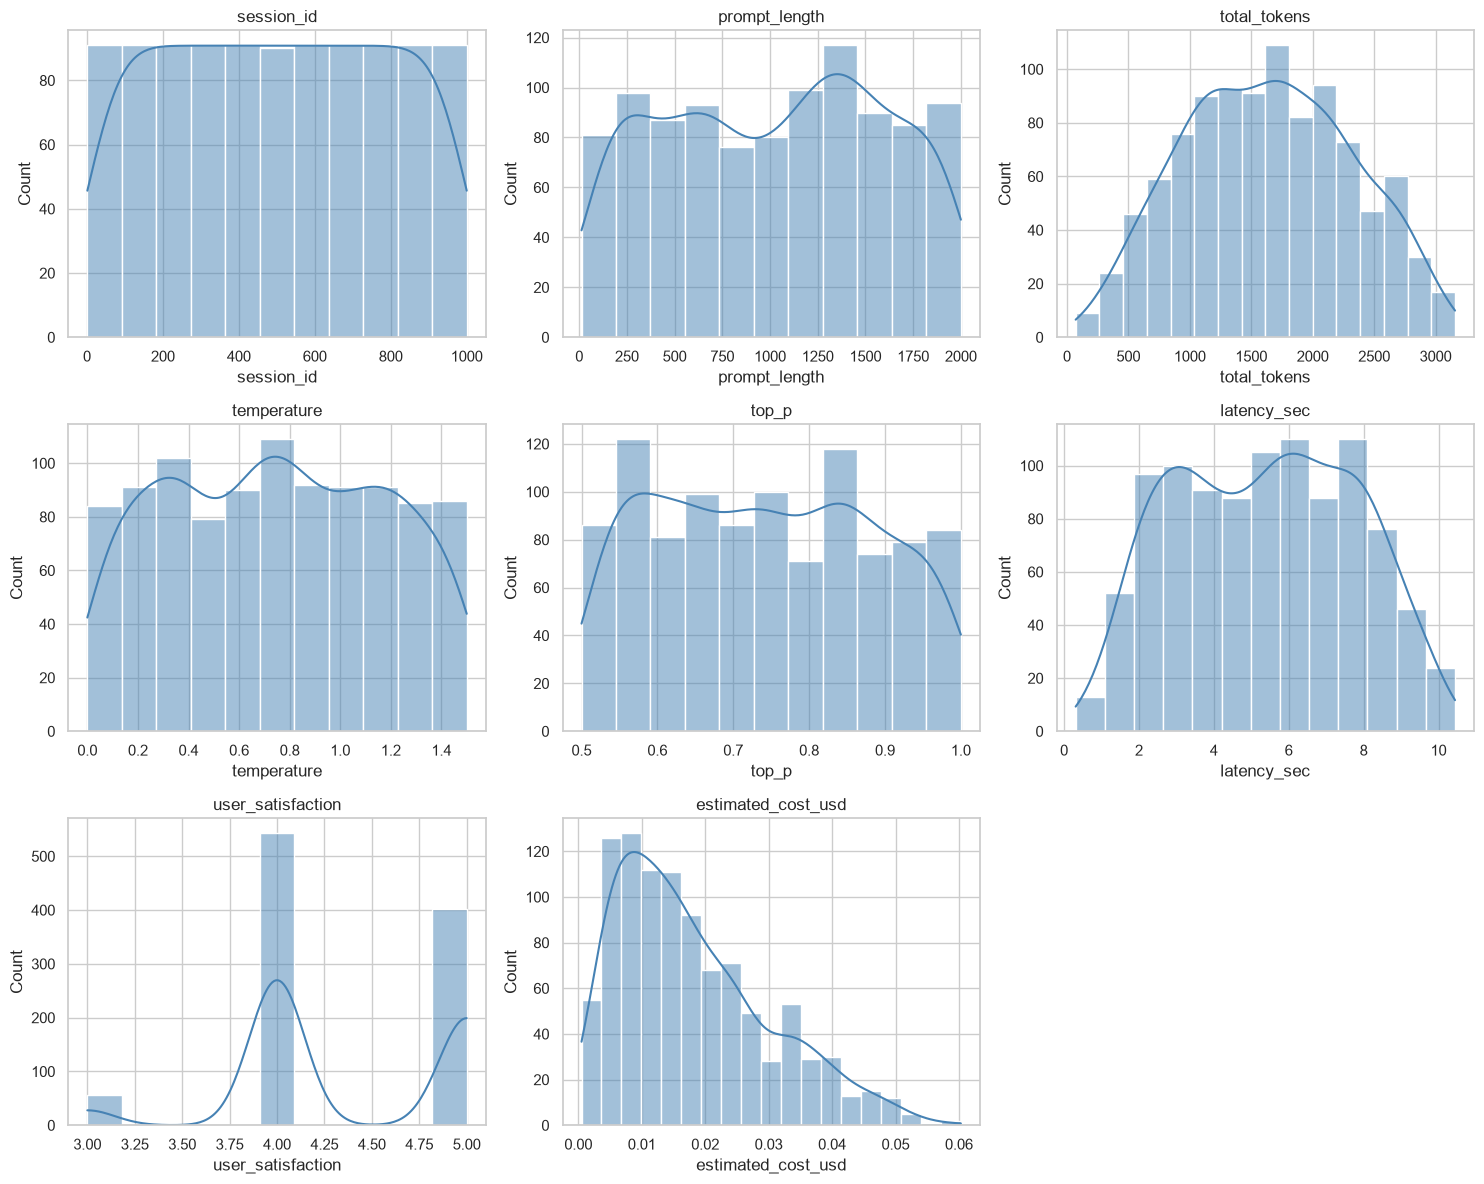

In [9]:
if numeric_cols:
    n = len(numeric_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns to plot.")


## 6. Box plots (spread & outliers) for numeric columns

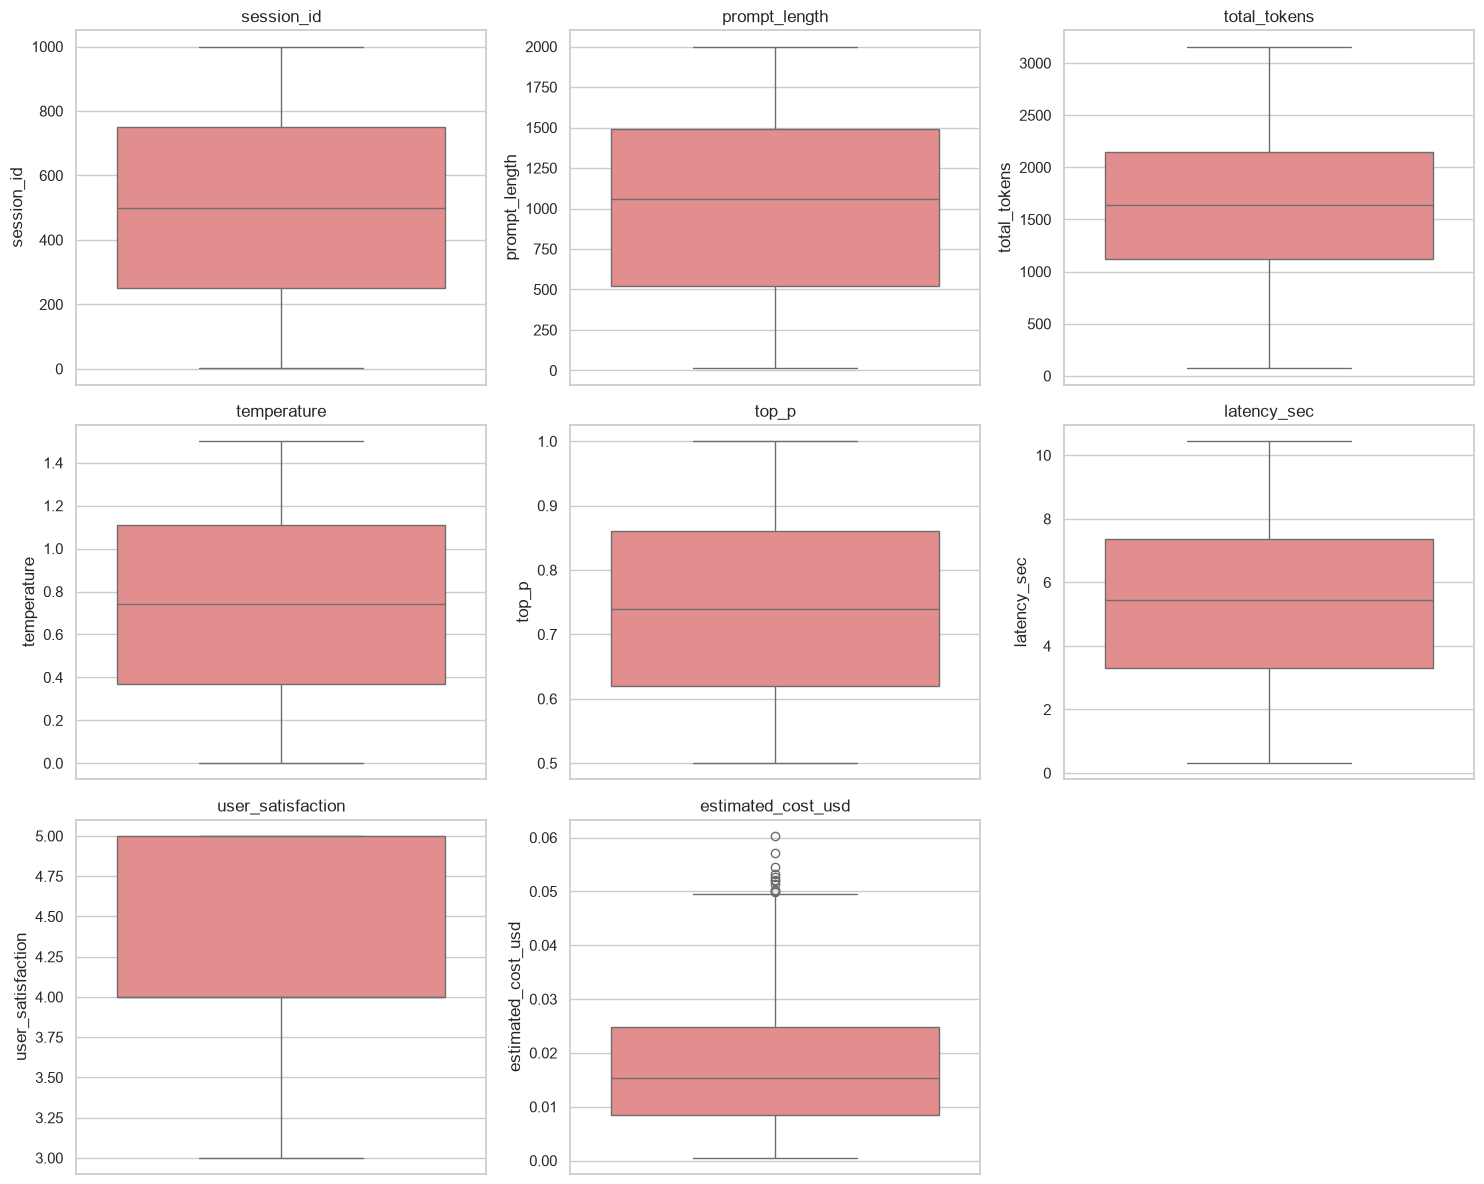

In [10]:
if numeric_cols:
    n = len(numeric_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns to plot.")


## 7. Correlation heatmap

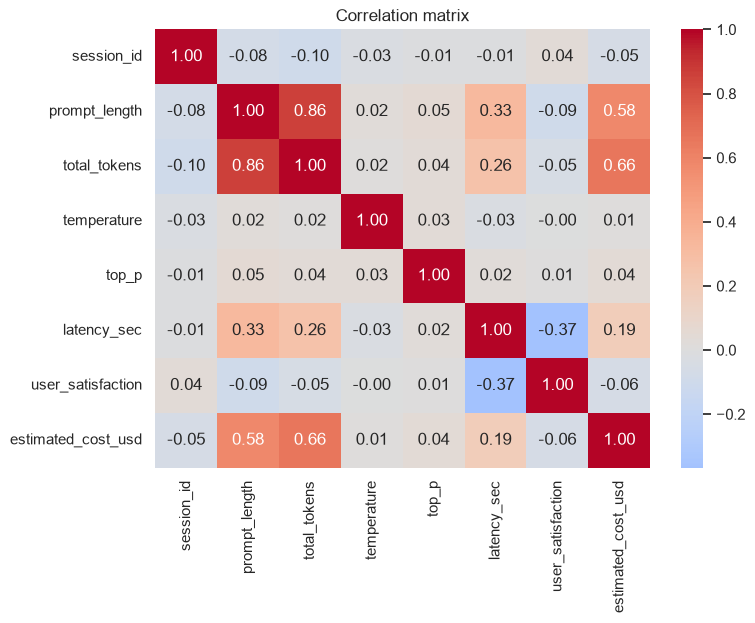

In [11]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(max(6, len(numeric_cols)), max(5, len(numeric_cols) * 0.8)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Correlation matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 numeric columns for a correlation heatmap.")


## 8. Pairwise relationships (scatter matrix)

In [70]:
if len(numeric_cols) >= 2:
    cols_for_pairplot = numeric_cols[:MAX_NUMERIC_FOR_PAIRPLOT]
    hue_col = categorical_cols[0] if categorical_cols and df[categorical_cols[0]].nunique() <= 8 else None

    g = sns.pairplot(df, vars=cols_for_pairplot, hue=hue_col, diag_kind="kde", corner=True)
    g.fig.suptitle("Pairwise relationships" + (f" (colored by {hue_col})" if hue_col else ""), y=1.02)
    plt.show()
else:
    print("Need at least 2 numeric columns for a pairplot.")


Need at least 2 numeric columns for a pairplot.


## 9. Categorical columns — bar charts

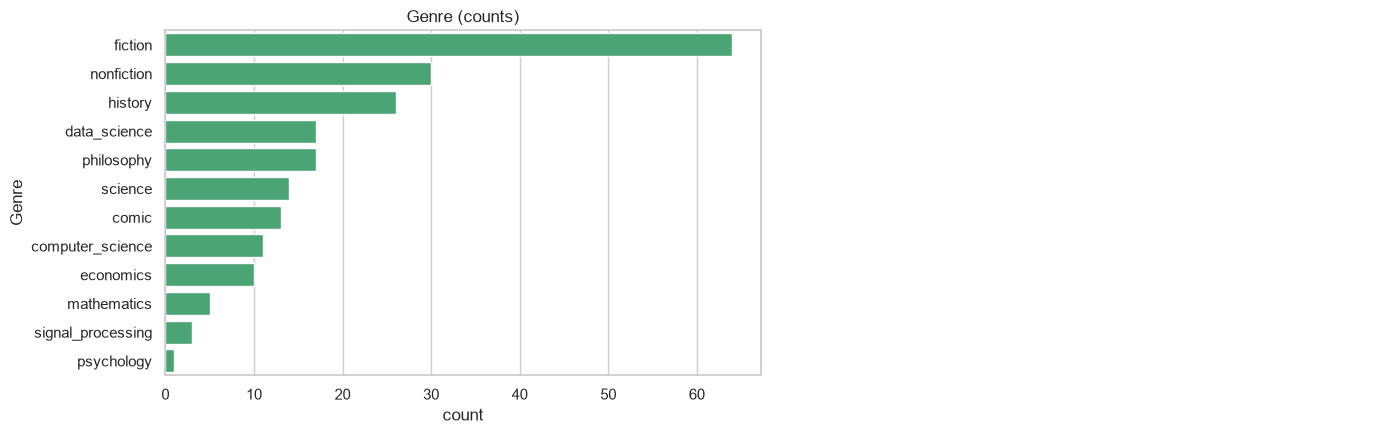

In [71]:
plot_cats = [c for c in categorical_cols if df[c].nunique(dropna=True) <= MAX_CATEGORIES_FOR_BAR]

if plot_cats:
    n = len(plot_cats)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cats):
        counts = df[col].value_counts(dropna=False).head(20)
        sns.barplot(x=counts.values, y=counts.index.astype(str), ax=axes[i], color="mediumseagreen")
        axes[i].set_title(f"{col} (counts)")
        axes[i].set_xlabel("count")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with a reasonable number of categories to bar-chart.")


## 10. Categorical columns — pie charts (low-cardinality only)

In [72]:
pie_cats = [c for c in categorical_cols if 1 < df[c].nunique(dropna=True) <= MAX_CATEGORIES_FOR_PIE]

if pie_cats:
    n = len(pie_cats)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(pie_cats):
        counts = df[col].value_counts(dropna=True)
        axes[i].pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%", startangle=90)
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No columns with a small enough number of categories for a pie chart.")


No columns with a small enough number of categories for a pie chart.


## 11. Numeric distribution split by category (box plots)

In [73]:
if numeric_cols and categorical_cols:
    split_cats = [c for c in categorical_cols if 1 < df[c].nunique(dropna=True) <= 10]

    if split_cats:
        cat_col = split_cats[0]
        cols_to_plot = numeric_cols[:6]
        n = len(cols_to_plot)
        ncols = 2
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(cols_to_plot):
            sns.boxplot(x=df[cat_col], y=df[col], ax=axes[i])
            axes[i].set_title(f"{col} by {cat_col}")
            axes[i].tick_params(axis="x", rotation=45)

        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No categorical column with a suitable number of groups (2-10) found.")
else:
    print("Need at least one numeric and one categorical column.")


No categorical column with a suitable number of groups (2-10) found.


## 12. Time series (if any datetime columns were detected)

In [74]:
if datetime_cols and numeric_cols:
    date_col = datetime_cols[0]
    ts = df[[date_col] + numeric_cols].dropna(subset=[date_col]).sort_values(date_col)

    cols_to_plot = numeric_cols[:6]
    n = len(cols_to_plot)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols_to_plot):
        axes[i].plot(ts[date_col], ts[col], color="darkorange")
        axes[i].set_title(f"{col} over {date_col}")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No datetime column (or no numeric columns) detected — skipping time series plots.")


No datetime column (or no numeric columns) detected — skipping time series plots.


## 13. Text / high-cardinality columns — quick look

In [75]:
if text_cols:
    for c in text_cols:
        print(f"\n--- {c} ---  ({df[c].nunique()} unique values)")
        display(df[c].dropna().sample(min(SAMPLE_ROWS_FOR_TEXT, df[c].dropna().shape[0]), random_state=0).to_frame())
else:
    print("No free-text / high-cardinality columns detected.")



--- Title ---  (210 unique values)


,Title
173,"Cathedral and the Bazaar, The"
74,"Last Mughal, The"
12,Birth of a Theorem
5,"Nature of Statistical Learning Theory, The"
55,Soft Computing & Intelligent Systems



--- Author ---  (129 unique values)


,Author
110,"Rand, Ayn"
45,"Durant, Will"
178,"Rand, Ayn"
63,"Stroud, Jonathan"
127,"Durrell, Gerald"


## Notes

- Column roles (numeric / categorical / datetime / text) are re-detected every time you run
  the notebook, based purely on the data — nothing is hard-coded to specific column names.
- Tweak the knobs in the **CONFIG** cell (max categories, sample sizes, etc.) if a particular
  CSV needs different thresholds; the rest of the notebook adapts automatically.
- To use a new file, just update `CSV_PATH` in cell 2 and re-run all cells
  (Kernel → Restart & Run All).
